### 工作進度  
* 【置頂】**筆記內容架構**與**量化技術分析系統**相關資訊請參閱[260315筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/260315%E7%AD%86%E8%A8%98.ipynb)之「工作進度」。  

* 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

* 更新量化技術分析資料庫  

In [3]:
mysys.UpdateStockDatabase()

2026-04-02 23:22:52.139 | INFO     | FinMind.data.finmind_api:login_by_token:84 - Login success
2026-04-02 23:22:52.193 | INFO     | FinMind.data.finmind_api:login_by_token:84 - Login success
2026-04-02 23:22:52.206 | INFO     | FinMind.data.finmind_api:get_data:153 - download TaiwanStockInfo, data_id: 
2026-04-02 23:22:52.690 | INFO     | FinMind.data.finmind_api:get_data:153 - download TaiwanStockPrice, data_id: 


##### 更新台股總覽 #####
##### 更新技術分析資料 #####
【略過】日Ｋ：2026-03-23
【略過】週Ｋ：2026-03-23


2026-04-02 23:22:59.429 | INFO     | FinMind.data.finmind_api:get_data:153 - download TaiwanStockPrice, data_id: 


【略過】日Ｋ：2026-03-24


2026-04-02 23:23:04.785 | INFO     | FinMind.data.finmind_api:get_data:153 - download TaiwanStockPrice, data_id: 


...

【略過】日Ｋ：2026-03-31


2026-04-02 23:23:38.822 | INFO     | FinMind.data.finmind_api:get_data:153 - download TaiwanStockPrice, data_id: 


【略過】日Ｋ：2026-04-01


2026-04-02 23:23:44.328 | INFO     | FinMind.data.finmind_api:get_data:153 - download TaiwanStockPrice, data_id: 


【新建】日Ｋ：2026-04-02


* 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

> **盤前**：[【K線捕手｜十秒鐘看台股】](https://www.facebook.com/kevinyang20180801/posts/pfbid02Fejy6ebHn7KkfcNgijYPC9SCT8x58jff5RB8hymCVZPD7YJuAgkvDYQfNkoHEhQyl)   
> 👉 整理時間已超過一個月，箱型開始放大  
> 因此——  
> 5日、10日、20日線將出現「上下擺盪」  
> 📌 短期均線參考價值下降  
> ➡️ 接下來重點：  
> 回歸「箱型區間」看支撐與壓力  
> 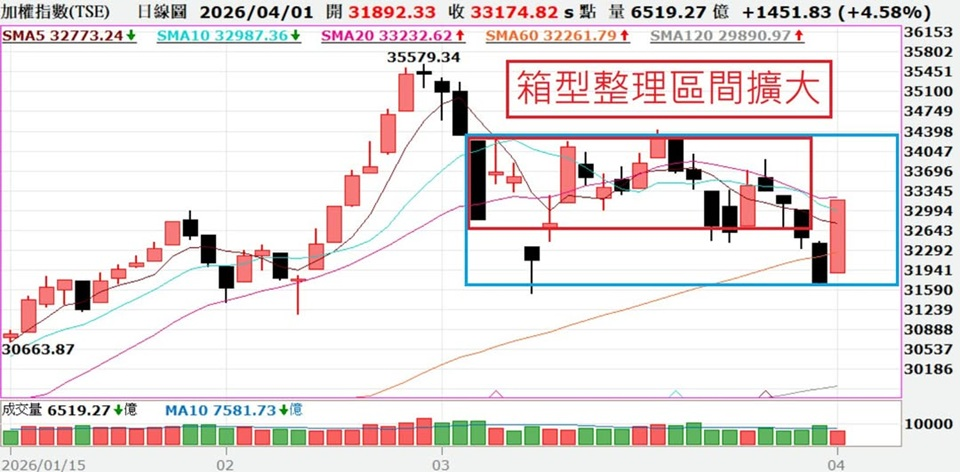  

In [5]:
def line_drawing_callback( range_prices) :

    resistance_line_start_date = '2026-03-03'
    resistance_line_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price      = range_prices.loc['2026-03-18']['Close'] 

    surport_line_start_date = resistance_line_start_date
    surport_line_end_date   = resistance_line_end_date
    surport_line_price      = range_prices.loc['2026-03-31']['Close'] 


    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)],
        [(surport_line_start_date,surport_line_price),(surport_line_end_date,surport_line_price)]
    ]

    linewidths=[2.5,2.5]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

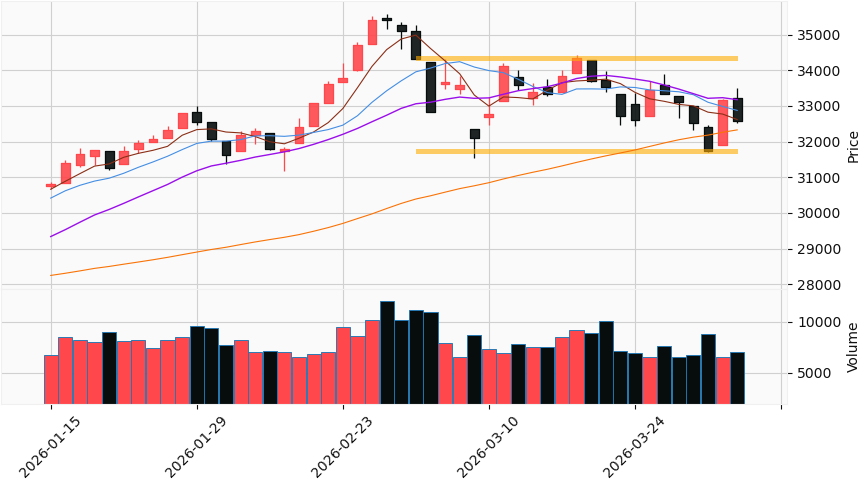

In [6]:
# 盤後：箱型整理區間
image = mysys.DrawOnKlineChart('TAIEX','2026-01-15','2026-04-02',line_drawing_callback)
display(image)

> **盤後**：量化技術分析  

解盤內容：


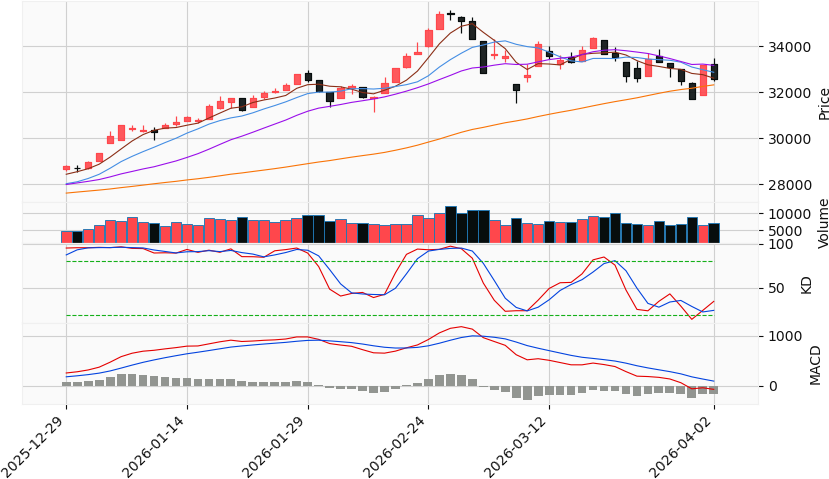

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2026-03-27
Ｋ線圖,中期為中位階 長期為高位階
成交量,價量關係：成交量小於十日均量（成交量 ＝ 7026.09億元 ，十日均量 ＝ 7399.94億元）
型態,反轉型態之雙重底，型態範圍由2026-03-03開始到2026-04-02結束，估算目標價為37317.96點。
移動平均線,5日線下彎、10日線下彎，短期翻空；20日線下彎、60日線上揚，中期盤整；120日線上揚、240日線上揚，長期翻多
ＫＤ指標,於2026-04-01黃金交叉。
ＭＡＣＤ指標,（中期多空不明）
週Ｋ－週ＫＤ指標,於2026-03-02當週死亡交叉。
整體評價,"價格趨勢 近期走勢以下跌為主：高點回落後反彈力道不足，價格多次受制於上方均線帶，短線仍偏弱。雖然曾出現急彈，但隨後再度收低，顯示反彈較偏技術性修正，尚未扭轉結構。 價量關係 下跌段成交量有放大跡象，代表賣壓在回落時較積極；反彈時量能未能有效延續，追價意願偏保守。近期量能約落在6,500～8,800億元區間，屬於有量但未形成明確攻擊量的型態。 支撐與壓力 - 支撐：先看前低與近期回測區 31,700點附近；若失守，下一道支撐看 32,300點附近的中期均線位置（跌破後易轉為壓力、站回才算回穩）。 - 壓力：上方先看短期均線與反彈高點密集區 32,600點～32,900點；再上去為 33,200點～33,500點區間，屬於前波反彈高點與均線帶壓力。 KD指標解讀 KD自超賣區附近回升，K線已上穿D線，顯示短線有止跌回穩的修復動能。但目前仍在相對低檔區，KD回升較偏反彈訊號，仍需價格能站穩關鍵壓力區才有利延伸。 MACD指標解讀 DIF位於MACD線下方且仍在零軸下，整體動能偏弱，代表中短線趨勢仍由空方主導。柱狀體雖有收斂跡象，但尚未翻正，較像是跌勢趨緩而非明確轉多。 綜合評價 目前以空方趨勢中的反彈修復看待：價格仍受均線帶壓制，MACD動能未轉強前，反彈較容易在壓力區遇到賣壓。操作上可把「能否站穩 32,600點～32,900點」視為短線轉強關卡；若再度跌破 31,700點，則需提防回檔延續。"


In [7]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **盤後**：量化技術分析  

解盤內容：


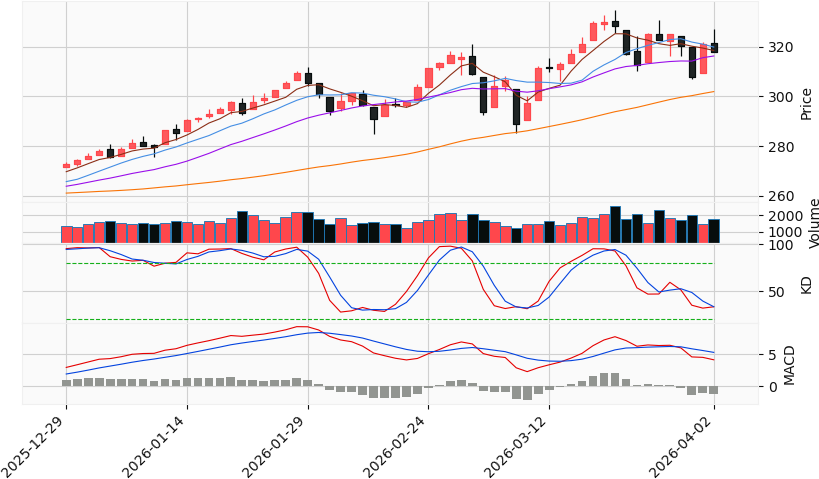

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2026-03-27
Ｋ線圖,中期為高位階 長期為高位階
成交量,價量關係：成交量小於十日均量（成交量 ＝ 1798.54億元 ，十日均量 ＝ 1921.5億元）
型態,反轉型態之三重頂，型態範圍由2026-01-12開始到2026-04-02結束，估算目標價為236.03點。
移動平均線,5日線下彎、10日線下彎，短期翻空；20日線上揚、60日線上揚，中期翻多；120日線上揚、240日線上揚，長期翻多
ＫＤ指標,於2026-03-30死亡交叉。
ＭＡＣＤ指標,MACD雙線在零軸以上，中期多方
週Ｋ－週ＫＤ指標,於2026-03-23當週黃金交叉。
整體評價,價格趨勢 整體仍屬上漲趨勢中的回檔整理：價格維持在中期均線之上，但短線自高檔拉回後，近幾日呈現區間震盪。短期均線走勢轉趨下彎並貼近價格，顯示短線動能偏弱、以整理消化為主。 價量關係 回檔段出現量能放大、反彈時量能相對收斂，屬於拉回帶量、反彈量縮的型態，短線偏向賣壓仍在。近期雖有反彈K線，但未能延續放量上攻，顯示追價意願不足。 支撐與壓力 - 支撐：先看 316點（中期均線附近的支撐帶），再看 307點（前波回檔低點）。 - 壓力：上方先看 320點（短期均線與近期整理區上緣），再看 327點（近端反彈高點）；若未能站穩320點，反彈較易轉為弱勢整理。 KD指標解讀 KD落在中低檔區且K、D線貼近，短線偏弱但已接近整理末端的狀態；目前未進入明確超賣區，因此不宜單憑KD視為反轉。就近幾日走勢來看，KD未能有效上彎，代表反彈續航力仍不足。 MACD指標解讀 DIF位於MACD線下方且柱狀體維持偏弱，顯示動能仍在收縮、偏空方掌控，短線反彈較像技術性修正。若後續柱狀體能由負值明顯收斂並帶動DIF上拐，才有利於回到較強的上攻節奏。 綜合評價 目前屬多頭架構未破、但短線動能偏弱的回檔整理；操作上以「守支撐、等動能轉強」較有利。觀察重點為 316點能否守穩，以及能否帶量站回 320點並突破 327點，否則仍以區間震盪偏弱看待。


In [8]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股篩選  

* 選股程序    

In [9]:
results = analysis.screener()

In [10]:
for stock_info in results :
    print('股票代碼 ＝ {} ， 股票名稱 ＝ {} '.format(stock_info[0],stock_info[1]))

股票代碼 ＝ 6405 ， 股票名稱 ＝ 悅城 
股票代碼 ＝ 2409 ， 股票名稱 ＝ 友達 
股票代碼 ＝ 5243 ， 股票名稱 ＝ 乙盛-KY 
股票代碼 ＝ 2497 ， 股票名稱 ＝ 怡利電 


* 篩選結果  
  - 建漢(3062)：多頭回檔／已到壓力區  
    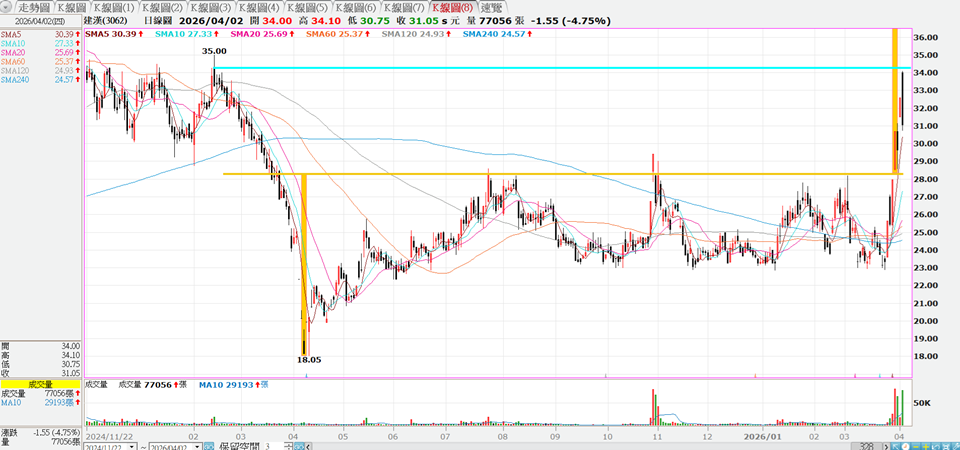  
  - 悅城(6405)：技術突破  
    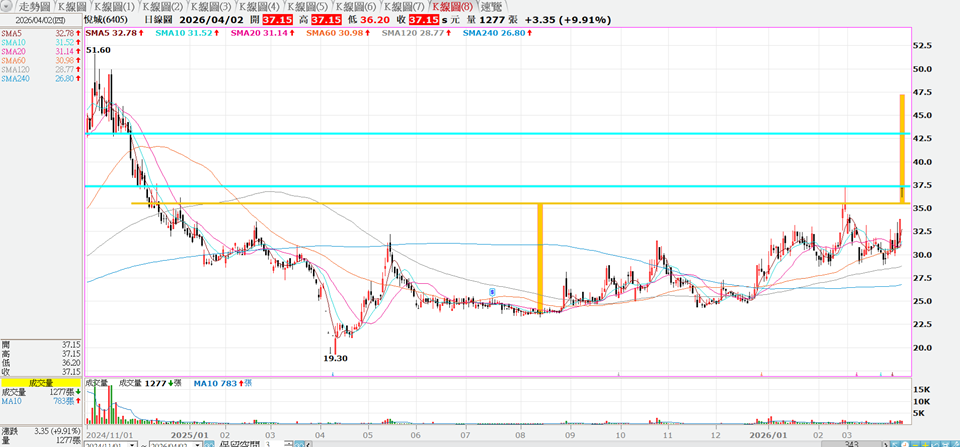  

* 觀察股列表  
  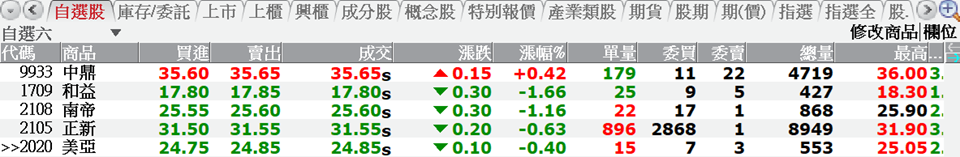  

### 個股解盤  

* 大成(1210)  
  看法：非強勢突破底部型態，因此需觀察之後是否能夠持續站在頸線之上。  

> **盤後**：量化技術分析   

解盤內容：


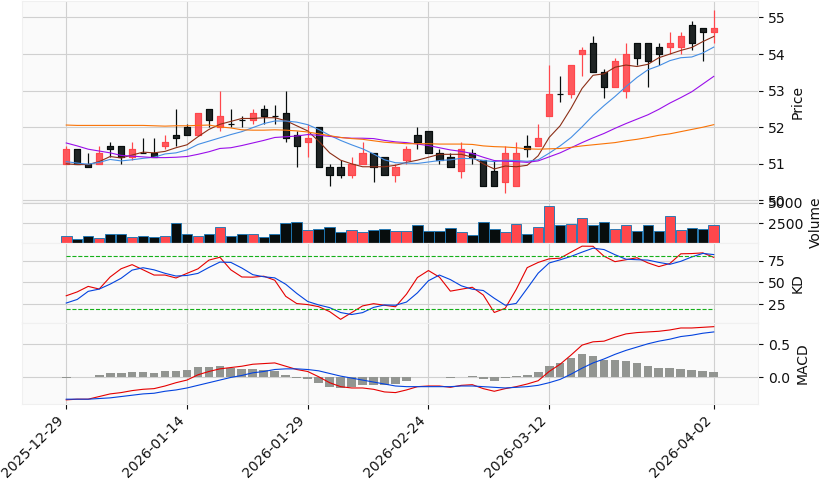

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2026-03-27 , 2026-04-02 孕育線／懷抱線 : 2026-04-01"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：成交量大於十日均量，但未至大量門檻（成交量 ＝ 2294張 ，十日均量 ＝ 2077張）
型態,底型反轉之底部型態，型態範圍由2025-09-17開始到2026-03-27結束，2026-04-02時已達估算之目標價（55.00元）。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線上揚、240日線走平，長期盤整
ＫＤ指標,於2026-04-02死亡交叉。
ＭＡＣＤ指標,MACD雙線在零軸以上，中期多方
週Ｋ－週ＫＤ指標,於2026-03-02當週黃金交叉。
整體評價,"價格趨勢 整體為上漲格局，近期K線沿短期均線上方推進並維持高檔震盪，低點逐步墊高。均線呈現短期均線在上、中期均線在下的多頭排列，趨勢結構偏多。 價量關係 近期上攻過程中成交量未見連續放大，屬於價漲量縮/量能跟進不足的型態，偏向高檔整理後再選方向。若後續要再攻高，需觀察紅K推進時成交量是否能同步放大至約2,300張以上並延續。 支撐與壓力 - 支撐：先看54.5元附近（短期均線與近期收盤密集區），跌破則看54.2元，再來是53.8元（近期回檔低點）作為關鍵防守。 - 壓力：上方先看55.2元（近期高點），若帶量突破，下一道壓力落在55.7元附近（長期均線反壓區）。 KD指標解讀 KD位於高檔區，近期出現K線走弱、K值回落且K線下穿D線的現象，顯示短線動能有降溫跡象。由於仍在高檔，KD不宜單獨視為反轉訊號，需搭配價格是否跌破支撐與MACD動能續航判斷。 MACD指標解讀 DIF維持在MACD線之上且兩者仍向上，代表中期動能仍偏多未破壞。惟柱狀體連續縮小，顯示多方動能趨緩，短線較可能以高檔整理或小幅回檔來消化。 綜合評價 目前屬於多頭趨勢中的高檔整理：趨勢與均線結構偏多，但量能與MACD柱狀體顯示續攻力道轉弱。操作上以守54.5元/54.2元支撐、看55.2元壓力是否帶量突破作為多空分界；若跌破53.8元，則需提高對回檔擴大的警覺。"


In [11]:
stock_analysis(analysis,'1210')

> **盤後**：底部反轉交易策略分析   

In [12]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-10-23'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-11-10']['Open']

    # 設定底部日期與價格
    bottom_date  = '2026-03-04'
    bottom_price = range_prices.loc['2026-03-04']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)]
    ]

    linewidths=[2.0,10.0,10.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

估算目標價為57.40元


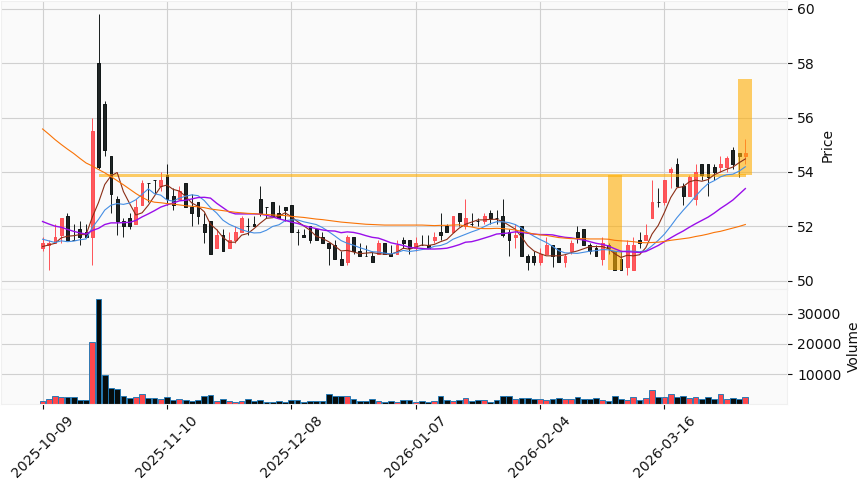

In [13]:
image = mysys.DrawOnKlineChart('1210','2025-10-09','2026-04-02',line_drawing_callback)
display(image)

籌碼面：  
法人大買(+1119)：外資大買(+1111)、投信小買(+28)、自營小賣(-20)。  
主力大買(+846)。  
分公司買賣家數差集中(+167)。  
融資中立(+3)、融券中立(0)。  